# 1. Podaci

Za trening je koriscen podskup skupa nvidia/OpenCodeInstruct. Statistika pripremljenog skupa ucitava se iz `data/dataset_summary.json`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
summary = json.loads((ROOT / "data/dataset_summary.json").read_text(encoding="utf-8"))

## Filtriranje i izbor

Zadrzani su primeri sa prosecnim test score-om najmanje 0,8, prosecnom LLM ocenom najmanje 4 i najvise 1.024 tokena posle formatiranja. Uklonjeni su duplikati normalizovanih promptova i primeri koji se poklapaju sa benchmark promptovima ili imenima funkcija. Provera slicnosti ukljucivala je i zajednicke nizove od osam reci.

Od preostalih primera stratifikovano je izabrano 22.000 redova prema domenu, nacinu generisanja i kvartilu duzine. Podela je uradjena sa seed-om 42.

In [2]:
pd.Series({
    "Izvorni skup": summary["source_rows"],
    "Posle filtera": summary["eligible_after_filtering"],
    "Izabrano": summary["selected_rows"],
}, name="Broj primera").to_frame()

,Broj primera
Izvorni skup,5000000
Posle filtera,1372043
Izabrano,22000


## Sastav izabranog skupa

Granice kvartila, izracunate na skupu prihvatljivih kandidata, jesu 347, 424 i 535 tokena. Izabrani podskup priblizno zadrzava raspodelu po ovim kvartilima.

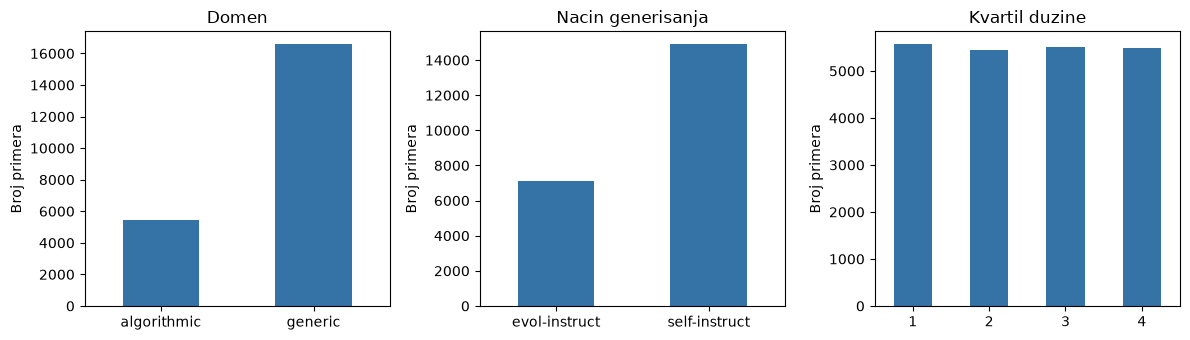

In [3]:
distributions = [
    ("Domen", summary["selected_domain_counts"]),
    ("Nacin generisanja", summary["selected_generation_algorithm_counts"]),
    ("Kvartil duzine", summary["selected_length_quartile_counts"]),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (title, counts) in zip(axes, distributions):
    pd.Series(counts).plot.bar(ax=ax, color="#3572a5", rot=0)
    ax.set(title=title, ylabel="Broj primera")
plt.tight_layout()
plt.show()

## Podela

Trening skup sadrzi 20.000, a validacioni 2.000 primera. Pilot od 1.000 primera je deo trening skupa. HumanEval+ i MBPP+ su odvojeni test skupovi.

Tabela prikazuje velicine i namenu skupova. Parquet fajlovi nisu potrebni za pokretanje ovog notebooka.

In [4]:
pd.DataFrame([
    ("Trening", summary["train_rows"], "Ucenje adaptera"),
    ("Validacija", summary["validation_rows"], "Loss i perplexity"),
    ("HumanEval+", 164, "Test generisanih resenja"),
    ("MBPP+", 378, "Test generisanih resenja"),
], columns=["Skup", "Broj primera", "Namena"])

,Skup,Broj primera,Namena
0,Trening,20000,Ucenje adaptera
1,Validacija,2000,Loss i perplexity
2,HumanEval+,164,Test generisanih resenja
3,MBPP+,378,Test generisanih resenja


## Format za trening

Kolone `input` i `output` postaju korisnicka poruka i odgovor asistenta u Qwen chat sablonu. Na kraju se dodaje EOS token. Tokeni korisnicke poruke i padding dobijaju labelu `-100`, pa se loss racuna samo za odgovor.

Formatiranje i maskiranje implementirani su u [data.py](../src/code_lora/data.py).

Sledeca dva para su kratki, rucno napisani primeri za prikaz formatiranja. Koristimo isti tokenizer i funkcije kao u projektu. Potrebni su samo fajlovi tokenizatora: na projektnoj masini su vec u cache-u, a pri prvom pokretanju na drugoj masini preuzimaju se sa Hugging Face-a.

In [5]:
import sys
import yaml
from transformers import AutoTokenizer

sys.path.insert(0, str(ROOT / "src"))
from code_lora.data import completion_only_example, CompletionOnlyCollator

settings = yaml.safe_load((ROOT / "configs/experiment.yaml").read_text(encoding="utf-8"))
cache = ROOT / "huggingface_cache"
tokenizer = AutoTokenizer.from_pretrained(
    settings["model"]["id"], revision=settings["model"]["revision"], cache_dir=cache,
)
pairs = [
    ("Napisi funkciju zbir(a, b).", "def zbir(a, b):\n    return a + b"),
    ("Vrati nulu.", "def nula():\n    return 0"),
]
examples = [completion_only_example(tokenizer, prompt, answer) for prompt, answer in pairs]
print(tokenizer.decode(examples[0]["input_ids"]))

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Napisi funkciju zbir(a, b).<|im_end|>
<|im_start|>assistant
def zbir(a, b):
    return a + b<|im_end|>
<|endoftext|>


### Koji tokeni ulaze u loss?

Tabela pocinje neposredno pre odgovora asistenta. Labela `-100` iskljucuje token iz loss-a; za ostale pozicije labela je ID tokena odgovora. Pri racunanju causal-LM loss-a model pomera logite i labele za jednu poziciju: prethodni tokeni sluze za predvidjanje sledeceg.

In [6]:
example = examples[0]
answer_start = next(i for i, label in enumerate(example["labels"]) if label != -100)
tokens = pd.DataFrame({
    "Token": [repr(tokenizer.decode([token])) for token in example["input_ids"]],
    "ID": example["input_ids"],
    "Labela": example["labels"],
})
tokens.iloc[answer_start - 5:]

,Token,ID,Labela
35,'<|im_end|>',151645,-100
36,'\n',198,-100
37,'<|im_start|>',151644,-100
38,'assistant',77091,-100
39,'\n',198,-100
40,'def',750,750
41,' z',1147,1147
42,'bir',43855,43855
43,'(a',2877,2877
44,"','",11,11


### Formiranje batcha

Primeri su razlicite duzine. `CompletionOnlyCollator` dopunjava kraci primer paddingom sa desne strane. Padding dobija attention masku 0 i labelu `-100`; tokeni prompta imaju attention masku 1 i labelu `-100`, jer model vidi prompt iako na njemu ne racuna loss.

In [7]:
batch = CompletionOnlyCollator(tokenizer)(examples)
print("Oblik input_ids, attention_mask i labels:", tuple(batch["input_ids"].shape))
pd.DataFrame({
    "Tokeni bez paddinga": batch["attention_mask"].sum(dim=1).tolist(),
    "Padding tokeni": (batch["attention_mask"] == 0).sum(dim=1).tolist(),
    "Tokeni za loss": (batch["labels"][:, 1:] != -100).sum(dim=1).tolist(),
}, index=["zbir", "nula"])

Oblik input_ids, attention_mask i labels: (2, 55)


,Tokeni bez paddinga,Padding tokeni,Tokeni za loss
zbir,55,0,15
nula,46,9,11
